In [36]:
# Import necessary libraries
import os
import sys
import gzip
import struct
from typing import List

import albumentations as albu  # Library for image augmentation
import cv2  # OpenCV library for image processing
import numpy as np
from tqdm import tqdm  # Library for progress bars

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader  # PyTorch utilities for data handling
import torchvision.models as models  # Pre-trained models provided by PyTorch

from datasets import load_dataset  # Custom function to load dataset

from PIL import Image
import matplotlib.pyplot as plt  # Library for plotting graphs and images

In [40]:
torch.manual_seed(42)  # Set random seed for reproducibility

## Dataset - [Tiny ImageNet](https://huggingface.co/datasets/zh-plus/tiny-imagenet)


In [37]:
# Load the dataset using the load_dataset function with parameters "frgfm/imagenette" and "320px".
# The "frgfm/imagenette" dataset is being loaded with images resized to 320 pixels.
dataset = load_dataset("frgfm/imagenette", "320px")

# Define the number of labels in the dataset.
num_labels = 10

# Print the dataset object.
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 9469
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 3925
    })
})

In [38]:
# Access the training split of the dataset using the key "train".
# Then, access the 124th sample (indexing is 0-based) within the training split.
# Retrieve the image data associated with the sample.
image_data = dataset["train"][123]["image"]

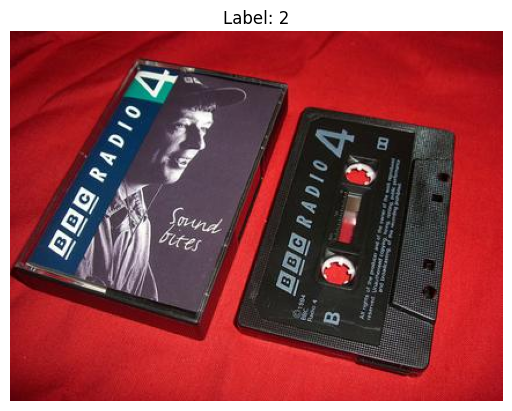

Class: cassette player


In [6]:
# Get one sample
sample = dataset["train"][123]  # 124th image from the training set
image = sample["image"]
label = sample["label"]

# Show the image
plt.imshow(image)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

print(f"Class: {dataset['train'].features['label'].int2str(label)}")


In [22]:
class HuggingFaceDataset(Dataset):
    """
    Define a custom dataset class named HuggingFaceDataset inheriting from the PyTorch Dataset class.
    """
    def __init__(self, dataset: Dataset, augmentations: albu.Compose) -> None:
        # Constructor method to initialize the dataset and augmentation transformations.
        self.dataset = dataset  # Store the input dataset
        self.augs = augmentations  # Store the augmentation transformations

    def __len__(self) -> int:
        # Override the len method to return the length of the dataset.
        return len(self.dataset)

    def __getitem__(self, index) -> tuple:
        # Override the getitem method to retrieve a sample from the dataset.
        sample = self.dataset[index]  # Get the sample at the specified index from the dataset

        # Convert the image to RGB format if it's not already in that format
        image = sample["image"].convert("RGB")

        # Apply the specified augmentations to the image
        image = self.augs(image=np.array(image))["image"]

        # Convert the augmented image to a PyTorch tensor and permute its dimensions
        if isinstance(image, np.ndarray):
          image = torch.from_numpy(image).permute(2, 0, 1)

        # Convert the label to a PyTorch LongTensor
        label = torch.LongTensor([sample["label"]])

        # Return the augmented image and its corresponding label as a tuple
        return image, label


In [23]:
# Set the batch size for training
batch_size = 10

# Define the input shape for the images (height, width).
# NOTE: To speed up training, you can decrease the input shape, but it may affect the final performance.
input_shape = (224, 224)

# Set the number of workers for data loading to be the number of available CPU cores
workers = os.cpu_count()

# Define the augmentation transformations for training images
# TODO: optional, play with augmentations
train_augs = albu.Compose([
    albu.Resize(input_shape[0], input_shape[1]),
    albu.HorizontalFlip(p=0.5),
    albu.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
    albu.RandomBrightnessContrast(p=0.5),
    albu.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    albu.pytorch.ToTensorV2()
])

# Create a DataLoader for training data using the defined augmentations
train_loader = DataLoader(
    HuggingFaceDataset(dataset["train"], train_augs),
    batch_size=batch_size,
    shuffle=True,
    num_workers=workers,
    pin_memory=True
)

# Define the augmentation transformations for validation images
valid_augs = albu.Compose([
    albu.Resize(input_shape[0], input_shape[1]),
    albu.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    albu.pytorch.ToTensorV2()
])

# Create a DataLoader for validation data using the defined augmentations
valid_loader = DataLoader(
    HuggingFaceDataset(dataset["validation"], valid_augs),
    batch_size=batch_size,
    shuffle=False,
    num_workers=workers,
    pin_memory=True
)

/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:58: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [24]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    device: str = "cpu",
    verbose: bool = True
) -> dict:
    """
    Function to train the model for one epoch.

    Args:
    - model: The neural network model to be trained.
    - loader: DataLoader object for loading the training data.
    - criterion: Loss function criterion.
    - optimizer: Optimizer for updating model parameters.
    - device: Device to run the model on (default is "cpu").
    - verbose: If True, print progress during training.

    Returns:
    - logs: Dictionary containing average loss and accuracy.
    """
    model.train()  # Set the model to training mode

    losses = []
    accuracies = []

    loop = tqdm(loader, disable=not verbose)

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()  # Reset gradients
        outputs = model(images)  # Forward pass

        loss = criterion(outputs, labels.squeeze())
        loss.backward()  # Backward pass
        optimizer.step()  # Update parameters

        # Save loss and accuracy
        losses.append(loss.item())
        accuracies.append((outputs.argmax(1) == labels.squeeze()).float().mean().item())

        loop.set_postfix(loss=loss.item(), accuracy=accuracies[-1])  # Show live metrics if verbose

    logs = {
        "loss": np.mean(losses),
        "accuracy": np.mean(accuracies)
    }

    return logs

In [25]:
@torch.inference_mode()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: str = "cpu",
    verbose: bool = True,
) -> dict:
    """
    Function to evaluate the model on the validation or test set.

    Args:
    - model: The neural network model to be evaluated.
    - loader: DataLoader object for loading the validation or test data.
    - criterion: Loss function criterion.
    - device: Device to run the model on (default is "cpu").
    - verbose: If True, print evaluation progress.

    Returns:
    - logs: Dictionary containing evaluation statistics (average loss and accuracy).
    """
    model.eval()  # Set the model to evaluation mode
    losses = []
    accuracies = []

    loop = tqdm(loader, desc="Evaluation", file=sys.stdout, ncols=100, disable=not verbose)

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels.squeeze())
        losses.append(loss.item())

        accuracy = (outputs.argmax(1) == labels.squeeze()).float().mean().item()
        accuracies.append(accuracy)

        # Display live metrics if verbose
        loop.set_postfix(loss=loss.item(), accuracy=accuracy)

    logs = {
        "loss": np.mean(losses),
        "accuracy": np.mean(accuracies)
    }

    return logs

In [26]:
# Check if CUDA (GPU) is available, otherwise use CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device - {device}\n")

# TODO: Find a model that gives the best score.
# Here, a pre-trained ResNet50 model is used as a starting point.
# You may experiment with other pre-trained models available in torchvision.models.
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)  # Load pre-trained ResNet18 model
model.fc = nn.Linear(model.fc.in_features, num_labels)  # Replace the fully connected layer with new output size
model = model.to(device)  # Move the model to the specified device (CPU or GPU)

print("Number of trainable parameters -", sum(p.numel() for p in model.parameters() if p.requires_grad))

# Define the optimizer for updating model parameters
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Define the loss function
loss_fn = nn.CrossEntropyLoss()

Device - cuda

Number of trainable parameters - 23528522


In [29]:
n_epochs = 20  # Number of epochs for training

train_losses = []  # List to store training losses for each epoch
train_accuracies = []  # List to store training accuracies for each epoch

valid_losses = []  # List to store validation losses for each epoch
valid_accuracies = []  # List to store validation accuracies for each epoch

# Loop through each epoch
for ep in range(n_epochs):
    print(f"\nEpoch {ep + 1:2d}/{n_epochs:2d}")

    # Train the model for one epoch and collect training statistics
    train_logs = train_one_epoch(model, train_loader, loss_fn, optimizer, device, verbose=True)
    train_losses.append(np.mean(train_logs["loss"]))
    train_accuracies.append(np.mean(train_logs["accuracy"]))
    print("      loss:", train_losses[-1])
    print("  accuracy:", train_accuracies[-1])

    # Evaluate the model on the validation set and collect evaluation statistics
    valid_logs = evaluate(model, valid_loader, loss_fn, device, verbose=True)
    valid_losses.append(np.mean(valid_logs["loss"]))  # Append the validation loss for the epoch
    valid_accuracies.append(np.mean(valid_logs["accuracy"]))  # Append the validation accuracy for the epoch
    print("      loss:", valid_losses[-1])  # Print the validation loss for the epoch
    print("  accuracy:", valid_accuracies[-1])  # Print the validation accuracy for the epoch



Epoch  1/20


100%|██████████| 947/947 [01:45<00:00,  8.95it/s, accuracy=1, loss=0.00107]


      loss: 0.0874265566932425
  accuracy: 0.9759239771549906
Evaluation: 100%|████████████████████████| 393/393 [00:15<00:00, 24.63it/s, accuracy=1, loss=0.0415]
      loss: 0.06160576208930791
  accuracy: 0.978625959719107

Epoch  2/20


100%|██████████| 947/947 [01:45<00:00,  8.99it/s, accuracy=1, loss=0.00468]


      loss: 0.06391155142490132
  accuracy: 0.9805702276315458
Evaluation: 100%|██████████████████████| 393/393 [00:15<00:00, 25.46it/s, accuracy=1, loss=0.000919]
      loss: 0.06698969589320379
  accuracy: 0.9806615836141067

Epoch  3/20


...

      loss: 0.03631523135367313
  accuracy: 0.9897571311203454
Evaluation: 100%|███████████████████████| 393/393 [00:15<00:00, 25.38it/s, accuracy=1, loss=0.00746]
      loss: 0.08824718617312904
  accuracy: 0.9725190916740863

Epoch 19/20


100%|██████████| 947/947 [01:45<00:00,  8.96it/s, accuracy=1, loss=0.00327]


      loss: 0.021466761814718658
  accuracy: 0.9936642048225484
Evaluation: 100%|██████████████████████| 393/393 [00:16<00:00, 24.33it/s, accuracy=1, loss=0.000107]
      loss: 0.09498278983188618
  accuracy: 0.975572525544931

Epoch 20/20


100%|██████████| 947/947 [01:45<00:00,  8.96it/s, accuracy=1, loss=0.000487]


      loss: 0.02505576439386566
  accuracy: 0.9920802561383313
Evaluation: 100%|███████████████████████| 393/393 [00:15<00:00, 25.13it/s, accuracy=1, loss=6.53e-6]
      loss: 0.13511655736329728
  accuracy: 0.9615776165751101


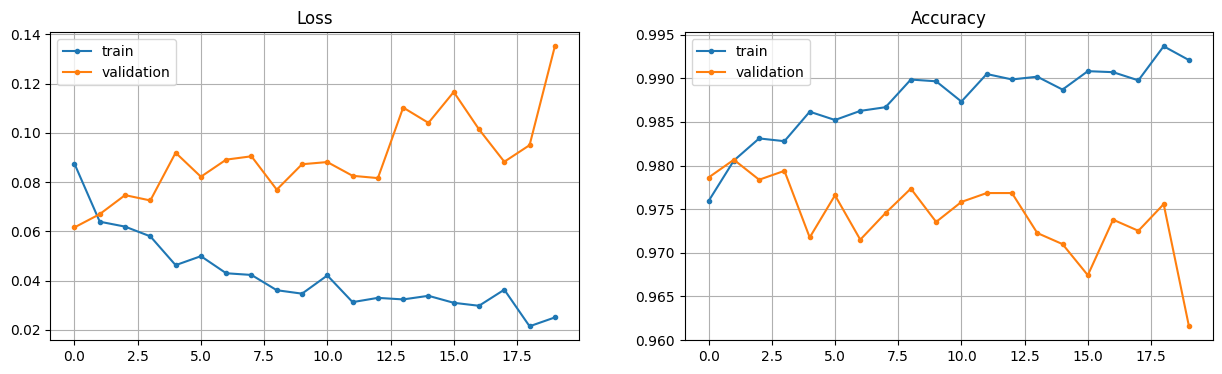

In [30]:
# Create a figure with two subplots side by side
fix, axes = plt.subplots(ncols=2, figsize=(15, 4))

# Plot the training and validation losses on the first subplot (axes[0])
axes[0].plot(np.arange(len(train_losses)), train_losses, ".-")  # Plot training losses
axes[0].plot(np.arange(len(valid_losses)), valid_losses, ".-")  # Plot validation losses
axes[0].legend(["train", "validation"])  # Add legend to distinguish between training and validation losses
axes[0].set_title("Loss")  # Set title for the subplot as "Loss"
axes[0].grid()  # Add grid lines to the plot

# Plot the training and validation accuracies on the second subplot (axes[1])
axes[1].plot(np.arange(len(train_accuracies)), train_accuracies, ".-")  # Plot training accuracies
axes[1].plot(np.arange(len(valid_accuracies)), valid_accuracies, ".-")  # Plot validation accuracies
axes[1].legend(["train", "validation"])  # Add legend to distinguish between training and validation accuracies
axes[1].set_title("Accuracy")  # Set title for the subplot as "Accuracy"
axes[1].grid();  # Add grid lines to the plot

In [32]:
# Check if CUDA (GPU) is available, otherwise use CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device - {device}\n")


model = models.efficientnet_v2_m(weights=models.EfficientNet_V2_M_Weights.IMAGENET1K_V1)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_labels) # Replace the fully connected layer with new output size
model = model.to(device)  # Move the model to the specified device (CPU or GPU)

print("Number of trainable parameters -", sum(p.numel() for p in model.parameters() if p.requires_grad))

# Define the optimizer for updating model parameters
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Define the loss function
loss_fn = nn.CrossEntropyLoss()

Device - cuda

Number of trainable parameters - 52871166


In [33]:
n_epochs = 10  # Number of epochs for training

train_losses = []  # List to store training losses for each epoch
train_accuracies = []  # List to store training accuracies for each epoch

valid_losses = []  # List to store validation losses for each epoch
valid_accuracies = []  # List to store validation accuracies for each epoch

# Loop through each epoch
for ep in range(n_epochs):
    print(f"\nEpoch {ep + 1:2d}/{n_epochs:2d}")

    # Train the model for one epoch and collect training statistics
    train_logs = train_one_epoch(model, train_loader, loss_fn, optimizer, device, verbose=True)
    train_losses.append(np.mean(train_logs["loss"]))
    train_accuracies.append(np.mean(train_logs["accuracy"]))
    print("      loss:", train_losses[-1])
    print("  accuracy:", train_accuracies[-1])

    # Evaluate the model on the validation set and collect evaluation statistics
    valid_logs = evaluate(model, valid_loader, loss_fn, device, verbose=True)
    valid_losses.append(np.mean(valid_logs["loss"]))  # Append the validation loss for the epoch
    valid_accuracies.append(np.mean(valid_logs["accuracy"]))  # Append the validation accuracy for the epoch
    print("      loss:", valid_losses[-1])  # Print the validation loss for the epoch
    print("  accuracy:", valid_accuracies[-1])  # Print the validation accuracy for the epoch



Epoch  1/10


100%|██████████| 947/947 [03:56<00:00,  4.01it/s, accuracy=1, loss=0.0857]


      loss: 0.21580037888072612
  accuracy: 0.9478352799728402
Evaluation: 100%|███████████████████████| 393/393 [00:26<00:00, 14.93it/s, accuracy=1, loss=0.00268]
      loss: 0.05098855623887418
  accuracy: 0.9847328292807853

Epoch  2/10


100%|██████████| 947/947 [03:56<00:00,  4.01it/s, accuracy=1, loss=0.0144]


      loss: 0.09221878517546948
  accuracy: 0.9758183805718468
Evaluation: 100%|███████████████████████| 393/393 [00:26<00:00, 14.79it/s, accuracy=1, loss=0.00753]
      loss: 0.06111499858960425
  accuracy: 0.9801526773370253

Epoch  3/10


...

      loss: 0.04223556887595714
  accuracy: 0.9870937505015098
Evaluation: 100%|████████████████████████| 393/393 [00:26<00:00, 14.84it/s, accuracy=1, loss=0.0167]
      loss: 0.09923930004246362
  accuracy: 0.974809166584306

Epoch  9/10


100%|██████████| 947/947 [03:58<00:00,  3.98it/s, accuracy=1, loss=0.00238]


      loss: 0.04826861271719858
  accuracy: 0.9863780400191592
Evaluation: 100%|██████████████████████| 393/393 [00:26<00:00, 14.70it/s, accuracy=1, loss=0.000177]
      loss: 0.12907578008974735
  accuracy: 0.9735369022565944

Epoch 10/10


100%|██████████| 947/947 [03:54<00:00,  4.04it/s, accuracy=1, loss=0.000264]


      loss: 0.03897574910174093
  accuracy: 0.9890179547865766
Evaluation: 100%|███████████████████████| 393/393 [00:26<00:00, 14.81it/s, accuracy=1, loss=0.00263]
      loss: 0.16335811089545288
  accuracy: 0.9687022979326224


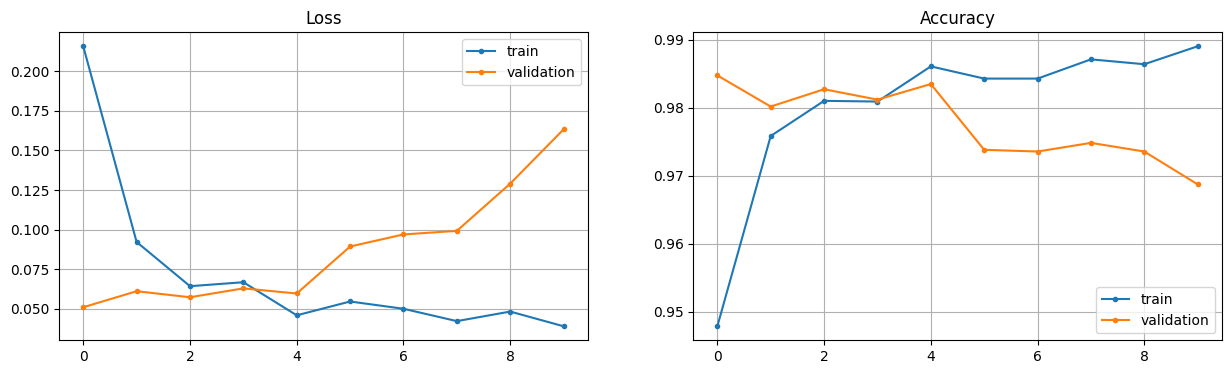

In [34]:
# Create a figure with two subplots side by side
fix, axes = plt.subplots(ncols=2, figsize=(15, 4))

# Plot the training and validation losses on the first subplot (axes[0])
axes[0].plot(np.arange(len(train_losses)), train_losses, ".-")  # Plot training losses
axes[0].plot(np.arange(len(valid_losses)), valid_losses, ".-")  # Plot validation losses
axes[0].legend(["train", "validation"])  # Add legend to distinguish between training and validation losses
axes[0].set_title("Loss")  # Set title for the subplot as "Loss"
axes[0].grid()  # Add grid lines to the plot

# Plot the training and validation accuracies on the second subplot (axes[1])
axes[1].plot(np.arange(len(train_accuracies)), train_accuracies, ".-")  # Plot training accuracies
axes[1].plot(np.arange(len(valid_accuracies)), valid_accuracies, ".-")  # Plot validation accuracies
axes[1].legend(["train", "validation"])  # Add legend to distinguish between training and validation accuracies
axes[1].set_title("Accuracy")  # Set title for the subplot as "Accuracy"
axes[1].grid();  # Add grid lines to the plot

In [41]:
# Check if CUDA (GPU) is available, otherwise use CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device - {device}\n")


model_vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
model_vit.heads.head = nn.Linear(model_vit.heads.head.in_features, num_labels)
model_vit = model_vit.to(device)

print("Number of trainable parameters -", sum(p.numel() for p in model.parameters() if p.requires_grad))

# Define the optimizer for updating model parameters
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Define the loss function
loss_fn = nn.CrossEntropyLoss()

Device - cuda



Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth
100%|██████████| 330M/330M [00:06<00:00, 54.2MB/s]


Number of trainable parameters - 52871166


In [42]:
n_epochs = 5  # Number of epochs for training

train_losses = []  # List to store training losses for each epoch
train_accuracies = []  # List to store training accuracies for each epoch

valid_losses = []  # List to store validation losses for each epoch
valid_accuracies = []  # List to store validation accuracies for each epoch

# Loop through each epoch
for ep in range(n_epochs):
    print(f"\nEpoch {ep + 1:2d}/{n_epochs:2d}")

    # Train the model for one epoch and collect training statistics
    train_logs = train_one_epoch(model, train_loader, loss_fn, optimizer, device, verbose=True)
    train_losses.append(np.mean(train_logs["loss"]))
    train_accuracies.append(np.mean(train_logs["accuracy"]))
    print("      loss:", train_losses[-1])
    print("  accuracy:", train_accuracies[-1])

    # Evaluate the model on the validation set and collect evaluation statistics
    valid_logs = evaluate(model, valid_loader, loss_fn, device, verbose=True)
    valid_losses.append(np.mean(valid_logs["loss"]))  # Append the validation loss for the epoch
    valid_accuracies.append(np.mean(valid_logs["accuracy"]))  # Append the validation accuracy for the epoch
    print("      loss:", valid_losses[-1])  # Print the validation loss for the epoch
    print("  accuracy:", valid_accuracies[-1])  # Print the validation accuracy for the epoch



Epoch  1/ 5


100%|██████████| 947/947 [03:53<00:00,  4.05it/s, accuracy=1, loss=0.000834]


      loss: 0.04577548116885986
  accuracy: 0.9862724437507179
Evaluation: 100%|███████████████████████| 393/393 [00:26<00:00, 14.97it/s, accuracy=1, loss=5.16e-5]
      loss: 0.4966730731542012
  accuracy: 0.9679389391236632

Epoch  2/ 5


100%|██████████| 947/947 [03:53<00:00,  4.05it/s, accuracy=1, loss=0.00216]


      loss: 0.03761669049014697
  accuracy: 0.9897571312462264
Evaluation: 100%|████████████████████████| 393/393 [00:26<00:00, 14.91it/s, accuracy=1, loss=0.0153]
      loss: 0.11730270279292798
  accuracy: 0.9715012797265866

Epoch  3/ 5


...

      loss: 0.040619231155873244
  accuracy: 0.9890179547236361
Evaluation: 100%|██████████████████████| 393/393 [00:26<00:00, 14.66it/s, accuracy=1, loss=0.000237]
      loss: 0.10186229920548673
  accuracy: 0.9715012804849154

Epoch  4/ 5


100%|██████████| 947/947 [03:52<00:00,  4.07it/s, accuracy=1, loss=0.00223]


      loss: 0.031375161105271526
  accuracy: 0.9909186937866896
Evaluation: 100%|███████████████████████| 393/393 [00:26<00:00, 14.97it/s, accuracy=1, loss=2.25e-5]
      loss: 0.5507358934452118
  accuracy: 0.9577608237436406

Epoch  5/ 5


100%|██████████| 947/947 [03:53<00:00,  4.06it/s, accuracy=1, loss=0.00362]


      loss: 0.04295679593274687
  accuracy: 0.9865892336260303
Evaluation: 100%|████████████████████████| 393/393 [00:26<00:00, 14.91it/s, accuracy=1, loss=0.0149]
      loss: 0.09497361146862762
  accuracy: 0.9732824503313797


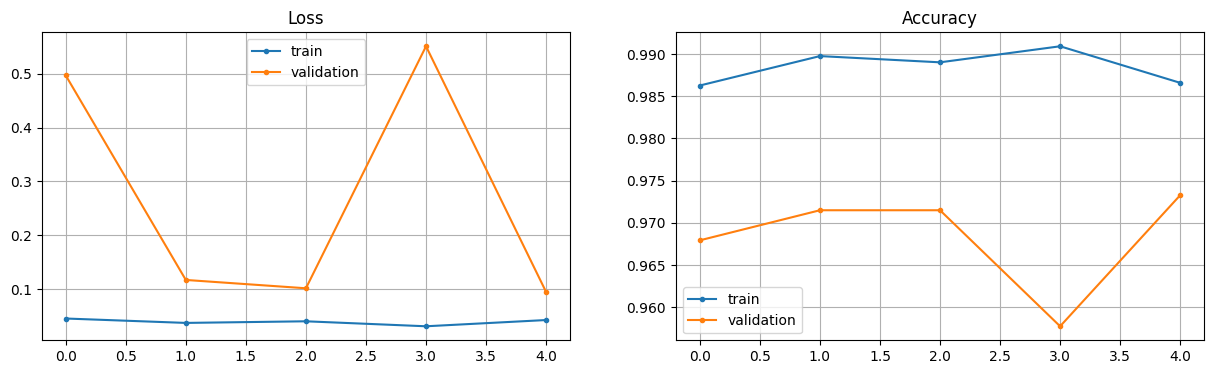

In [43]:
# Create a figure with two subplots side by side
fix, axes = plt.subplots(ncols=2, figsize=(15, 4))

# Plot the training and validation losses on the first subplot (axes[0])
axes[0].plot(np.arange(len(train_losses)), train_losses, ".-")  # Plot training losses
axes[0].plot(np.arange(len(valid_losses)), valid_losses, ".-")  # Plot validation losses
axes[0].legend(["train", "validation"])  # Add legend to distinguish between training and validation losses
axes[0].set_title("Loss")  # Set title for the subplot as "Loss"
axes[0].grid()  # Add grid lines to the plot

# Plot the training and validation accuracies on the second subplot (axes[1])
axes[1].plot(np.arange(len(train_accuracies)), train_accuracies, ".-")  # Plot training accuracies
axes[1].plot(np.arange(len(valid_accuracies)), valid_accuracies, ".-")  # Plot validation accuracies
axes[1].legend(["train", "validation"])  # Add legend to distinguish between training and validation accuracies
axes[1].set_title("Accuracy")  # Set title for the subplot as "Accuracy"
axes[1].grid();  # Add grid lines to the plot

***Key Observations and Comparisons:***

***Training and Evaluation Accuracy:***

***ResNet50:***

Generally achieved very high training accuracy (above 98%, often exceeding 99%).
Evaluation accuracy remained consistently high, mostly in the 97-98% range.
There were some fluctuations in evaluation accuracy, indicating potential overfitting in later epochs.

***EfficientNet:***

Showed good training and evaluation accuracy, with both consistently above 97%.
Evaluation accuracy was very consistent, staying within a narrow band.
Training accuracy was a little lower than Resnet50 in most epochs.

***ViT-b-16:***

Achieved high training accuracy, similar to ResNet50.
Evaluation accuracy fluctuated more significantly compared to the other models.
The evaluation loss was very high in some epochs.

***Training and Evaluation Loss:***

***ResNet50:***

Training loss decreased steadily, indicating good learning.
Evaluation loss showed more variability, suggesting some overfitting.

***EfficientNet:***

Training and evaluation loss were relatively stable, indicating consistent performance.
The evaluation loss was much more stable than Resnet50, and ViT.

***ViT-b-16:***

Training loss decreased well.
Evaluation loss was very erratic, with some very high values. This indicates that the ViT model was less stable during evaluation on this dataset than the other models.

***Training Time:***

***ResNet50:***
Relatively fast training per epoch (approximately 1 minute and 45 seconds).

***EfficientNet:***

Significantly slower training per epoch (approximately 3 minutes and 55 seconds).

***ViT-b-16:***

Training per epoch was very similar to EfficientNet, around 3 minutes and 53 seconds.

***Overfitting:***

Resnet50 showed signs of minor overfitting in later epochs. This is common for very deep neural networks.
EfficientNet showed less sign of overfitting.
ViT-b-16 also had signs of overfitting, but also had signs of instability in the evaluation phase. The wildly fluctuating evaluation loss is a sign of this.

***Number of Epochs:***

It is worth noting that ResNet50 was trained for 20 epochs, EfficientNet for 10 epochs, and ViT-b-16 for 5 epochs. This will have an impact on the overall performance.

***Conclusions:**

**ResNet50:**

A strong performer with high accuracy, but susceptible to overfitting.
Faster training time.

**EfficientNet:**

Excellent consistency and stability in both training and evaluation.
Less prone to overfitting.
Slower than Resnet50.

**ViT-b-16:**

Achieved high training accuracy, but exhibited instability and significant fluctuations in evaluation performance.
Also a slower training time.
May require further hyperparameter tuning or more extensive training data to stabilize performance.

**Recommendations:**

If speed is a crucial factor, ResNet50 is a viable option, but monitor for overfitting.
If stability and consistency are priorities, EfficientNet appears to be the best choice.
ViT-b-16 requires further work, such as more data or hyperparameter optimization, to gain a reliable performance.
In summary, EfficientNet performed the most consistently out of the 3 models tested.